# Survey Analysis, Part 2: Segment Analysis

Topline results hide as much as they reveal. The question this notebook answers: **do priorities differ by organization size, remoteness, or region?** If rural respondents want fundamentally different programs than urban ones, a single province-wide recommendation would be the wrong product.

The method: join survey responses to an organization attribute table, then compare selection rates for each program area across segments.

> **Note on data:** all data is synthetic and generated for demonstration.

## 1. Load and join organization attributes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

survey = pd.read_csv('data/synthetic_survey_responses.csv')
networks = pd.read_csv('data/network_attributes.csv')

completed = survey[survey['COMPLETED'] == 1].copy()
merged = completed.merge(networks, on='NETWORK_ID', how='left')

print(f"Completed responses: {len(merged)}")
networks.head()

Completed responses: 385


,NETWORK_ID,Network Name,Size,Remoteness,Region
0,1,Network 01,Small,Urban,Central
1,2,Network 02,Medium,Urban,Central
2,3,Network 03,Large,Urban,South
3,4,Network 04,Small,Rural,Central
4,5,Network 05,Small,Urban,North


## 2. Selection rates by segment

For each segment (e.g. Small / Medium / Large), this calculates the share of respondents in that segment who selected each program area. Rates rather than raw counts, because segments are different sizes.

In [2]:
program_labels = {
    'PROGRAMS_C1': 'After hours care',
    'PROGRAMS_C2': 'Cancer and palliative care',
    'PROGRAMS_C3': 'Child and youth health',
    'PROGRAMS_C4': 'Chronic disease management',
    'PROGRAMS_C5': 'Seniors and cognitive health',
    'PROGRAMS_C6': 'Indigenous health',
    'PROGRAMS_C7': 'Integrated and specialized care',
    'PROGRAMS_C8': "Maternal and women's health",
    'PROGRAMS_C9': 'Mental health programs',
    'PROGRAMS_C10': 'Prevention and lifestyle health',
}

def selection_rates_by_segment(data, segment_col, option_labels):
    """Share of respondents in each segment selecting each option."""
    flags = data[list(option_labels)].rename(columns=option_labels)
    grouped = flags.groupby(data[segment_col]).mean().T.round(3)
    grouped.index.name = 'Program area'
    return grouped

by_size = selection_rates_by_segment(merged, 'Size', program_labels)[['Small', 'Medium', 'Large']]
by_remoteness = selection_rates_by_segment(merged, 'Remoteness', program_labels)[['Urban', 'Rural', 'Remote']]
by_region = selection_rates_by_segment(merged, 'Region', program_labels)

by_size

Size,Small,Medium,Large
Program area,,,
After hours care,0.313,0.418,0.419
Cancer and palliative care,0.172,0.149,0.179
Child and youth health,0.299,0.127,0.248
Chronic disease management,0.567,0.590,0.504
Seniors and cognitive health,0.269,0.291,0.368
Indigenous health,0.172,0.209,0.154
Integrated and specialized care,0.343,0.261,0.188
Maternal and women's health,0.246,0.216,0.205
Mental health programs,0.537,0.455,0.538


## 3. Visualize: where do segments diverge?

A heatmap makes divergence scannable. Read down each column for a segment's profile; read across each row to see whether a program's importance is universal or context-dependent.

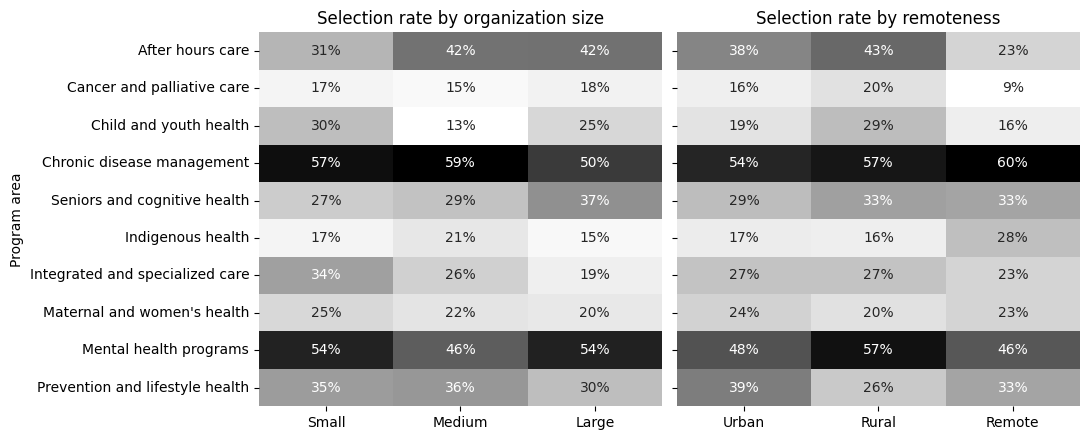

In [3]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

sns.heatmap(by_size, annot=True, fmt='.0%', cmap='Greys', cbar=False, ax=axes[0])
axes[0].set_title('Selection rate by organization size')
axes[0].set_xlabel('')

sns.heatmap(by_remoteness, annot=True, fmt='.0%', cmap='Greys', cbar=False, ax=axes[1])
axes[1].set_title('Selection rate by remoteness')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 4. Flag the biggest gaps

Rather than eyeballing the heatmap, compute the spread (max minus min selection rate) for each program across segments. Large spreads are where a one-size-fits-all recommendation would fail.

In [4]:
gaps = pd.DataFrame({
    'Spread by size': (by_size.max(axis=1) - by_size.min(axis=1)),
    'Spread by remoteness': (by_remoteness.max(axis=1) - by_remoteness.min(axis=1)),
}).round(3).sort_values('Spread by remoteness', ascending=False)

gaps

,Spread by size,Spread by remoteness
Program area,,
After hours care,0.106,0.201
Prevention and lifestyle health,0.059,0.136
Child and youth health,0.172,0.124
Indigenous health,0.055,0.117
Mental health programs,0.083,0.109
Cancer and palliative care,0.030,0.106
Chronic disease management,0.086,0.066
Seniors and cognitive health,0.099,0.045
Maternal and women's health,0.041,0.039


## 5. Export segment tables

In [5]:
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M')
file_name = f'survey_segment_analysis_{timestamp}.xlsx'

with pd.ExcelWriter(file_name) as writer:
    by_size.to_excel(writer, sheet_name='Programs by Size')
    by_remoteness.to_excel(writer, sheet_name='Programs by Remoteness')
    by_region.to_excel(writer, sheet_name='Programs by Region')
    gaps.to_excel(writer, sheet_name='Segment Gaps')

print(f"Exported segment tables to {file_name}")

Exported segment tables to survey_segment_analysis_20260611_2228.xlsx


## Why this step matters

In the real engagement this workflow is based on, segment analysis changed the recommendation. Priorities that looked settled at the provincial level diverged meaningfully between rural and urban contexts, which meant the policy product needed differentiated options rather than a single answer. The topline result alone would have pointed leadership in the wrong direction.